# Análisis Stack Overflow Developer Survey 2024
### Por Eugenio Vivani

Análisis exploratorio del dataset de Stack Overflow 2024 (65k+ respuestas).
Herramientas: Python · Pandas · Matplotlib

**Preguntas analizadas:**
1. ¿Cuáles son los lenguajes más usados?
2. ¿Qué porcentaje usa herramientas de IA?
3. ¿Cuáles son los roles mejor pagos?
4. ¿Cuántos años de experiencia tienen los roles de datos?
5. ¿Qué países tienen los salarios más altos?

In [1]:
import pandas as pd

# Cargamos el dataset
df = pd.read_csv('survey_results_public.csv')

# Vemos el tamaño
print(df.shape)

# Vemos las primeras filas
df.head()

(65437, 114)


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


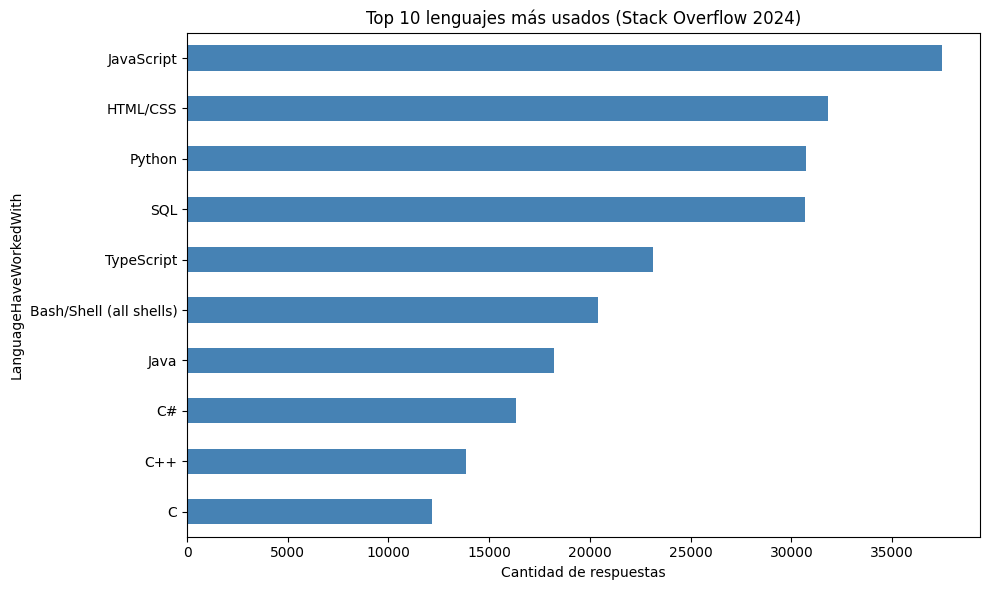

In [2]:
# Pregunta 1: ¿Cuáles son los lenguajes más usados?
import matplotlib.pyplot as plt

lenguajes = df['LanguageHaveWorkedWith'].dropna()
lenguajes = lenguajes.str.split(';').explode()
top_lenguajes = lenguajes.value_counts().head(10)

top_lenguajes.plot(kind='barh', figsize=(10,6), color='steelblue')
plt.title('Top 10 lenguajes más usados (Stack Overflow 2024)')
plt.xlabel('Cantidad de respuestas')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

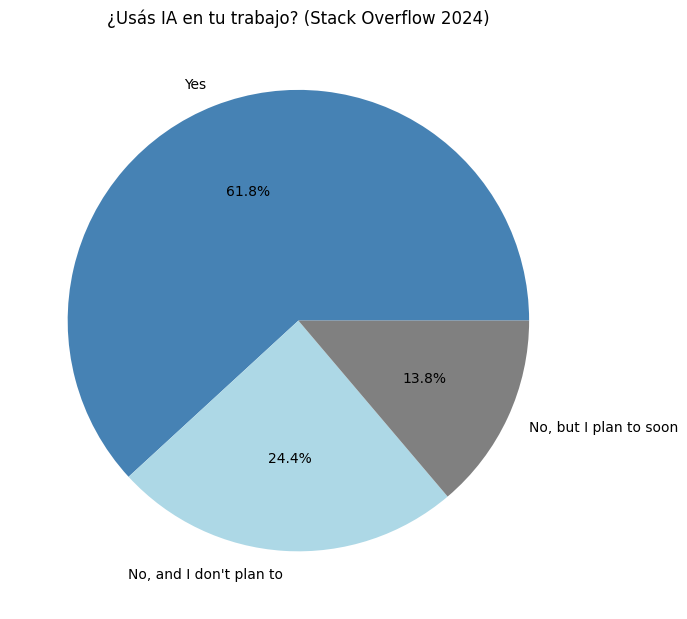

In [3]:
# Pregunta 2: ¿Qué porcentaje usa herramientas de IA?
ai_uso = df['AISelect'].value_counts()
colores = ['steelblue', 'lightblue', 'gray']

ai_uso.plot(kind='pie', figsize=(7,7), colors=colores, autopct='%1.1f%%')
plt.title('¿Usás IA en tu trabajo? (Stack Overflow 2024)')
plt.ylabel('')
plt.tight_layout()
plt.show()

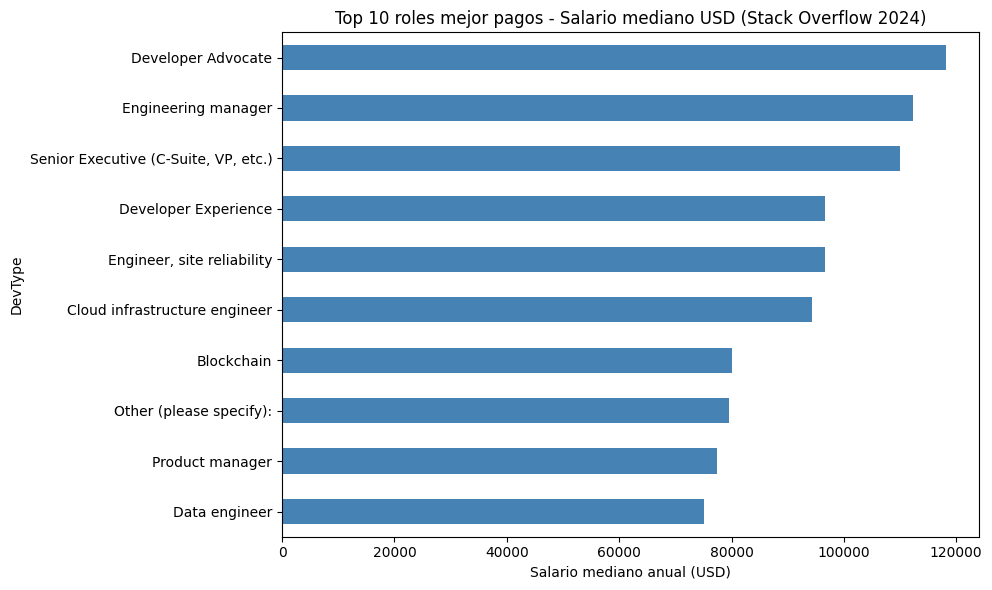

In [4]:
# Pregunta 3: ¿Cuáles son los roles mejor pagos?
salarios = df[['DevType', 'ConvertedCompYearly']].dropna()
salarios = salarios[salarios['ConvertedCompYearly'] < 300000]
salarios['DevType'] = salarios['DevType'].str.split(';')
salarios = salarios.explode('DevType')

top_roles = salarios.groupby('DevType')['ConvertedCompYearly'].median().sort_values(ascending=False).head(10)

top_roles.plot(kind='barh', figsize=(10,6), color='steelblue')
plt.title('Top 10 roles mejor pagos - Salario mediano USD (Stack Overflow 2024)')
plt.xlabel('Salario mediano anual (USD)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

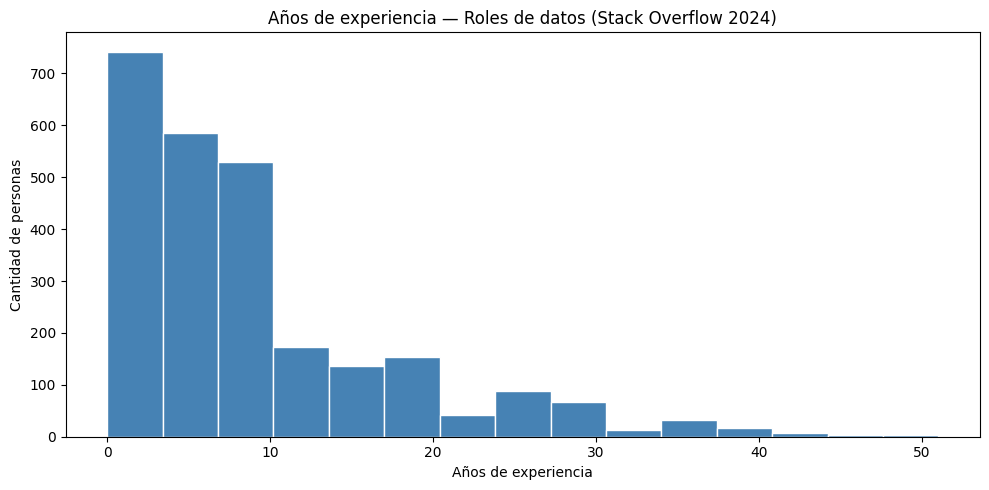

Mediana de experiencia: 6.0 años
Total en el dataset: 2591


In [7]:
# Pregunta 4 corregida: años de experiencia Data Analysts
da = df[df['DevType'].str.contains('Data', na=False)]
experiencia = da['YearsCodePro'].replace({'Less than 1 year': 0, 'More than 50 years': 51})
experiencia = pd.to_numeric(experiencia, errors='coerce').dropna()

experiencia.plot(kind='hist', bins=15, figsize=(10,5), color='steelblue', edgecolor='white')
plt.title('Años de experiencia — Roles de datos (Stack Overflow 2024)')
plt.xlabel('Años de experiencia')
plt.ylabel('Cantidad de personas')
plt.tight_layout()
plt.show()

print(f"Mediana de experiencia: {experiencia.median()} años")
print(f"Total en el dataset: {len(experiencia)}")

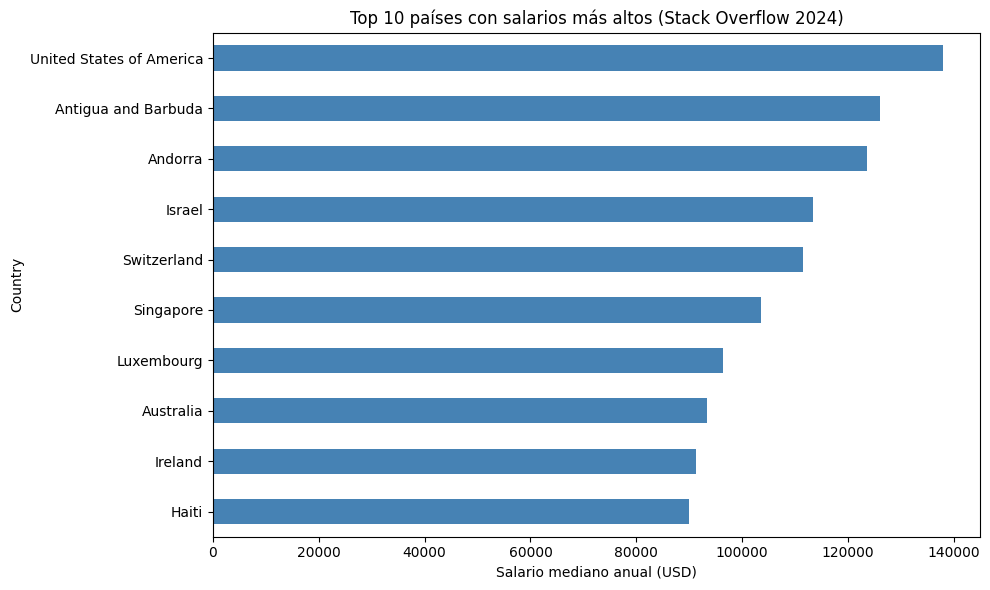

In [6]:
# Pregunta 5: ¿Qué países tienen los salarios más altos?
paises = df[['Country', 'ConvertedCompYearly']].dropna()
paises = paises[paises['ConvertedCompYearly'] < 300000]

top_paises = paises.groupby('Country')['ConvertedCompYearly'].median().sort_values(ascending=False).head(10)

top_paises.plot(kind='barh', figsize=(10,6), color='steelblue')
plt.title('Top 10 países con salarios más altos (Stack Overflow 2024)')
plt.xlabel('Salario mediano anual (USD)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()